# Frequency / NR ARFCN Experiment

## Data loading

In [1]:
import numpy as np

from scripts.data_filter import filter_dataframe
from scripts.data_loader import load_dataframe
from scripts.data_writer import save_experiment_result
from scripts.utils import NETWORK_TYPE

filename = "5G_data_2023.mat"

# Series of random seeds for reproducability
random_seeds = np.loadtxt('data/random_seeds.csv', dtype=int)

# load the dataframe from saved file or 'raw' matlab file
df = load_dataframe(filename, NETWORK_TYPE._5G)

# # Drop unused columns to save space
matrix_cols_to_drop = ['toa_pps', 'toa_cir', 'toa_cov', 'campaign_id']
df['measurements_matrix'] = df['measurements_matrix'].apply(
    lambda x: x.drop(columns=matrix_cols_to_drop)
)

selected_campaigns = list(range(1, 20))
# Data filtering
df = filter_dataframe(
    df=df,
    operators=[10],
    include_columns=['pci', 'beam_index', 'nr_arfcn', 'operator_id', 'rsrq'],
    campaigns=selected_campaigns,
)

Loaded dataframe from .h5 file: /Users/andreres/Documents/UIO/master/thesis/dev/5G_localization/data/dataframe_cache/5G_data_2023.h5


/Users/andreres/Documents/UIO/master/thesis/dev/5G_localization/scripts/data_filter.py:36: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["measurements_matrix"] = df["measurements_matrix"].apply(


## Run the experiment

In [4]:
from scripts.weighted_coverage import run_weighted_coverage
import pandas as pd
from scripts.utils import RF_PARAM_5G, extract_unique_npcis, replace_nr_arfcns, get_config

# Parameters
n_runs = 1
k_wknn = 2
rf_params = [RF_PARAM_5G.RSRQ]
clustering_rf_params = [RF_PARAM_5G.RSRQ]
n_clusters = 5
operator_choice = [10]

# merge simliar frequencies
config = get_config('frequency_map.json', '10')
nr_arfcn_frequecny_map = {int(k): int(v) for k, v in config.items()}

print(nr_arfcn_frequecny_map)

frequency_choice = list(set(nr_arfcn_frequecny_map.values())) + [0]
print('frequency_choice', frequency_choice)
replace_nr_arfcns(df, nr_arfcn_frequecny_map)

print(f"""
Running frequency experiment
🧪 Experiment setup 🧪
🔢 k-value for wKNN = {k_wknn}
👨‍👩‍👦‍👦 n clusters = {n_clusters}
🛜 RF PARAM {str(rf_params)}
📡 Cluster RF PARAM {str(clustering_rf_params)}
📶 Operator choice {operator_choice}
🔁 Number of runs {n_runs}|
_________________________________
""")

errors_dict = {nr: [] for nr in frequency_choice}  # Store the errors
num_entries_dict = {}

for nr in frequency_choice:
    if nr != 0:
        filtered_df = filter_dataframe(df=df.copy(), freqs=[nr])
    else:
        filtered_df = df.copy()

    unique_npcis = extract_unique_npcis(filtered_df['measurements_matrix'])

    num_entries_dict[nr] = [len(unique_npcis)]

    for i in range(n_runs):
        print(f"\r🔄 Running for nr_arfcn {nr} ({i + 1}/{n_runs} runs)", end="")
        _, errors, _, _ = run_weighted_coverage(
            df=filtered_df,
            rf_params=rf_params,
            cluster_rf_params=rf_params,
            k_max=k_wknn,
            unique_npcis=unique_npcis,
            random_seed=random_seeds[i],
            n_clusters=n_clusters,
        )
        errors_dict[nr].append(errors.mean())

    print(f"\r✅ {nr} completed                                           ")

errors_df = pd.DataFrame(errors_dict)
entries_df = pd.DataFrame(num_entries_dict)

# Save the results and config for reproducability and further processing and analysis
config = {
    'wknn_k': k_wknn,
    'rf_param': rf_params[0].value,
    'cluster_rf_param': clustering_rf_params[0].value,
    'operator_choice': operator_choice,
    'nr_arfcn_choice': frequency_choice,
    'n_clusters': n_clusters,
    'n_runs': n_runs,
}

data = {
    'errors': errors_df,
    'entries': entries_df,
}

save_experiment_result('frequency_experiment', config, data)

{432050: 2160, 643296: 3649, 643295: 3649, 432049: 2160, 432051: 2160, 156030: 780}
frequency_choice [2160, 3649, 780, 0]

Running frequency experiment
🧪 Experiment setup 🧪
🔢 k-value for wKNN = 2
👨‍👩‍👦‍👦 n clusters = 5
🛜 RF PARAM [<RF_PARAM_5G.RSRQ: 'rsrq'>]
📡 Cluster RF PARAM [<RF_PARAM_5G.RSRQ: 'rsrq'>]
📶 Operator choice [10]
🔁 Number of runs 1|
_________________________________

✅ 2160 completed                                           
✅ 3649 completed                                           
✅ 780 completed                                           
✅ 0 completed                                           
Experiment stored in ./data/results/experiments/frequency_experiment_6


# Plotting

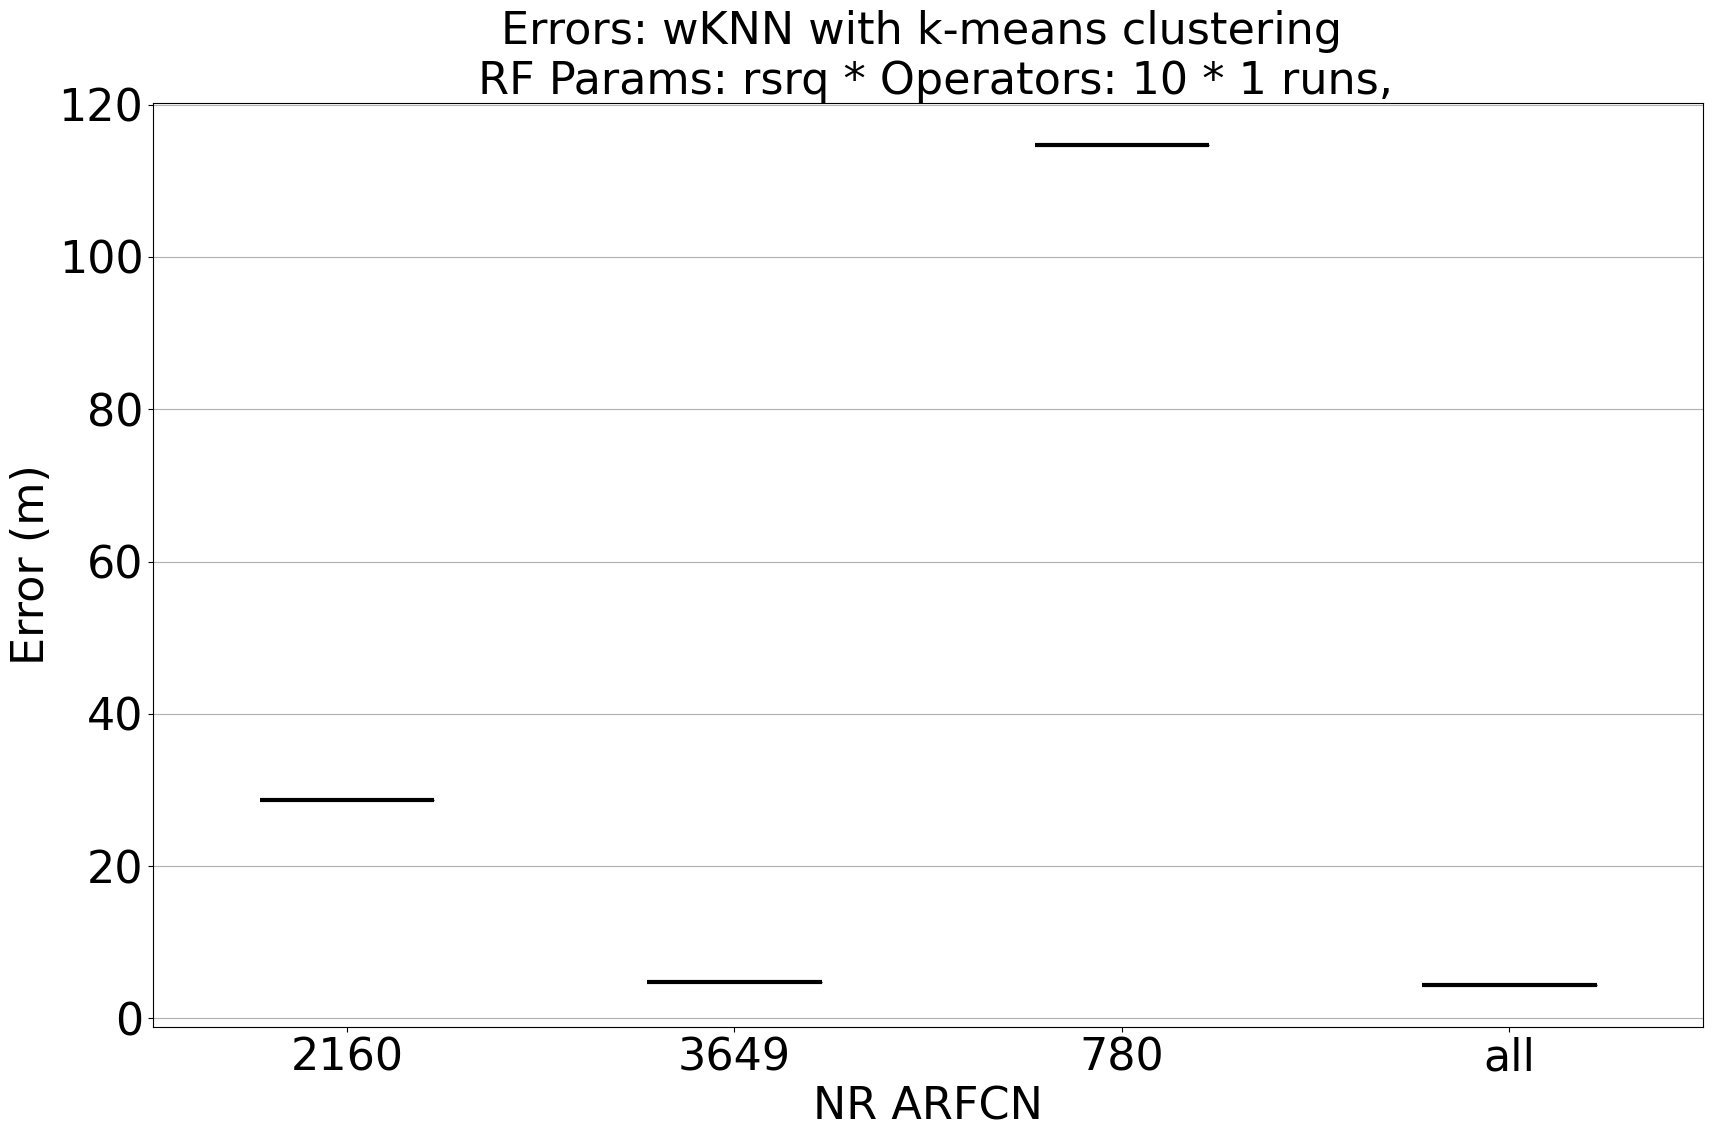

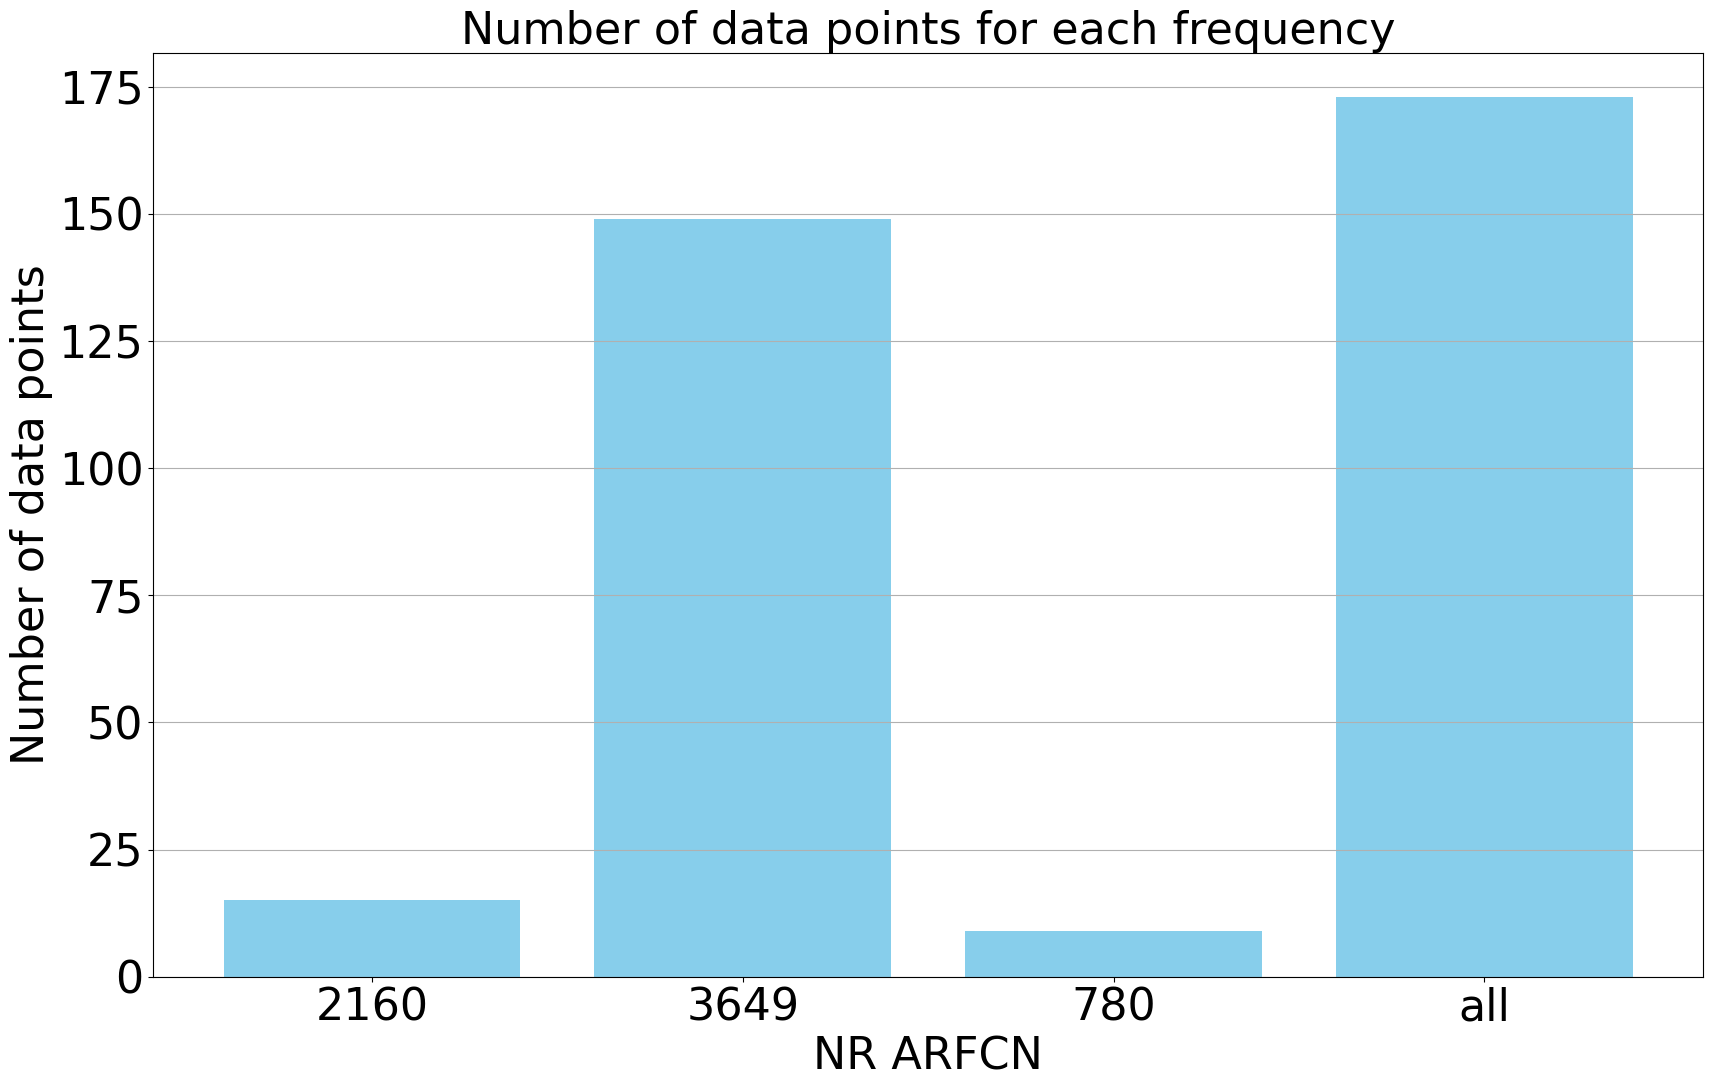

In [5]:
from scripts.plotting import make_boxplot, make_barplot
from scripts.utils import params_to_str, operators_to_str

# Plotting with capped runtime data
param_str = f'RF Params: {params_to_str(rf_params)}'
operator_str = f'Operators: {operators_to_str(operator_choice)}'
title_string = f"wKNN with k-means clustering \n {param_str} * {operator_str} * {n_runs} runs,"

errors_df = errors_df.rename(columns={col: 'all' if col == 0 else str(col) for col in errors_df.columns})
entries_df = entries_df.rename(columns={col: 'all' if col == 0 else str(col) for col in entries_df.columns})

make_boxplot(
    df=errors_df,
    title=f'Errors: {title_string}',
    x_label='NR ARFCN',
    y_label='Error (m)',
    color='mediumseagreen',
)

make_barplot(
    df=entries_df,
    title=f'Number of data points for each frequency',
    x_label='NR ARFCN',
    y_label='Number of data points',
)
